# Visualize Latents with ActMax

### Imports

In [1]:
import sys, os 
# sys.path.append(os.path.abspath('.'))

import torch
import torchaudio
import numpy as np
import gin
import rave
import types
import act_max_util as amu # no PCA
# import act_max_pca as amu # with PCA
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F

### Plotting functions

In [2]:
def plot_mel_spectrogram(mel_spectrogram, title='Mel Spectrogram', dB_scale=True, save_path=None):
    # Remove batch dimension if present
    if mel_spectrogram.dim() == 3 and mel_spectrogram.size(0) == 1:
        mel_spectrogram = mel_spectrogram[0]
    
    if dB_scale:
        mel_spectrogram = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram)
        
    else:
        # Normalize mel spectrogram to [0, 1] range
        mel_min = mel_spectrogram.min()
        mel_max = mel_spectrogram.max()
        if mel_max == mel_min:  # Avoid division by zero
            mel_spectrogram = mel_spectrogram - mel_min
        else:     # Normalize to [0, 1]
            mel_spectrogram = (mel_spectrogram - mel_min) / (mel_max - mel_min)

    plt.figure(figsize=(8, 7))
    plt.imshow(mel_spectrogram, origin="lower", aspect="auto", cmap="magma")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    if dB_scale:
        plt.colorbar(format="%+2.0f dB")
    else:
        plt.colorbar(label="Amplitude")
    if save_path:
        plt.savefig(save_path)
    plt.show()

### Load model

In [3]:
# Directory containing model checkpoint and config
model_dir = './checkpoints/noise_warmup_200k_latent_8'

# Load the model
config_path = rave.core.search_for_config(model_dir)
gin.parse_config_file(config_path)
model = rave.RAVE()
run = rave.core.search_for_run(model_dir)
model = model.load_from_checkpoint(run)


print(f'Model loaded from {model_dir}')
print(f'model.latent_size: {model.latent_size}')

model
vars(model.encoder.encoder.net[1])

/Users/DiarmuidFogarty/miniconda3/envs/RAVE/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model loaded from ./checkpoints/noise_warmup_200k_latent_8
model.latent_size: 8


{'training': True,
 '_parameters': {},
 '_buffers': {},
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': {'aligned': Branches(
    (branches): ModuleList(
      (0): DilatedUnit(
        (net): CachedSequential(
          (0): LeakyReLU(negative_slope=0.2)
          (1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), bias=False)
          (2): LeakyReLU(negative_slope=0.2)
          (3): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
        )
      )
      (1): Identity()
    )
  )},
 'c

### Initialize input

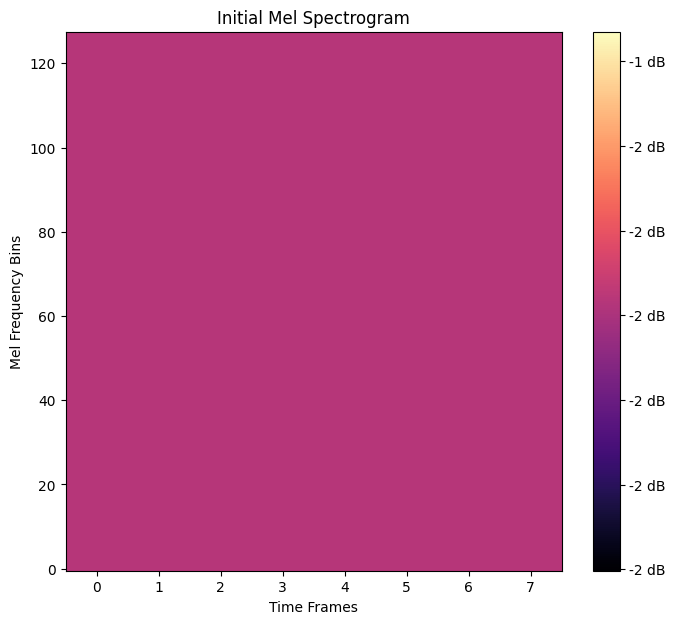

In [ ]:
# Create placeholder spectrogram input
n_mels = 128
C = 8 # compression ratio of encoder based on strides

initial_mel = torch.randn(1, n_mels, C)
initial_mel[:, :, :] = 10e-1 # NOTE: too small magnitude may lead to negatives in final optimal spectrogram

input = torch.log1p(initial_mel) # log scaling like in RAVE _mel_encode()

plot_mel_spectrogram(input, title='Initial Mel Spectrogram')

In [5]:
# # print(input.shape)
# x = torch.randn(1, n_mels, 7)
# conv = model.encoder.encoder.net[0]
# print(conv._pad)
# pad_left, pad_right = conv._pad
# torch.manual_seed(0)
# noise_pad = torch.randn(
#     x.shape[0], 
#     x.shape[1], 
#     pad_left + pad_right,
#     device=x.device,
#     dtype=x.dtype
# )
# print(noise_pad)
# torch.save(noise_pad, 'noise_pad.pt')
# x = torch.cat([
#                 noise_pad[..., :pad_left],
#                 x,
#                 noise_pad[..., pad_left:]
#             ], dim=-1)

# print(f'noise_pad.shape: {noise_pad.shape}')
# print(f'x.shape after padding: {x.shape}')
# # output = conv(input)
# # print(output.shape)

### Plot PCA component

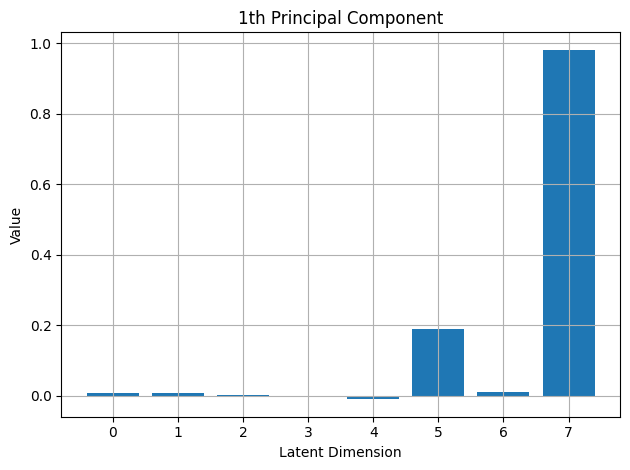

In [6]:
N = 0
pc = model.latent_pca[N]

plt.bar(np.arange(len(pc)), pc)
plt.title(f'{N+1}th Principal Component')
plt.xlabel('Latent Dimension')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### Create hook into final encoder layer

In [7]:
# Create hook into target layer
output_layer_encoder = model.encoder.encoder.net[-1]  # NOTE: (means, scales): (128,128)
layer_name = 'output_layer_encoder'
act_dict = {}
output_layer_encoder.register_forward_hook(amu.layer_hook(act_dict, layer_name))

### Prepare optimization

In [8]:
input.requires_grad_(True)  # enable gradient computation

# Parameters for activation maximization
steps = 200               # perform 100 iterations
units = range(model.latent_size)     # take all latents
alpha = torch.tensor(0.01)   # learning rate (step size) 
verbose = True              # print activation every step
L2_Decay = False             # enable L2 decay regularizer
Gaussian_Blur = True        # enable Gaussian regularizer
Norm_Crop = False            # enable norm regularizer
Contrib_Crop = False         # enable contribution regularizer

# pc = -pc # choose direction of PC to maximize

### Run ActMax

In [9]:
# Run activation maximization
output = amu.act_max(
    network=model,
    input=input,
    layer_activation=act_dict,
    layer_name=layer_name,
    units=units,
    steps=steps,
    alpha=alpha,
    verbose=verbose,
    L2_Decay=L2_Decay,
    Gaussian_Blur=Gaussian_Blur,
    Norm_Crop=Norm_Crop,
    Contrib_Crop=Contrib_Crop,
    update_viz=True,
    pc=pc
)

step:  0 activation:  tensor(5.2651, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6579, grad_fn=<DivBackward0>)
step:  1 activation:  tensor(5.2638, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6578, grad_fn=<DivBackward0>)
step:  2 activation:  tensor(5.2620, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6578, grad_fn=<DivBackward0>)
step:  3 activation:  tensor(5.2603, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6578, grad_fn=<DivBackward0>)
step:  4 activation:  tensor(5.2585, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6578, grad_fn=<DivBackward0>)
step:  5 activation:  tensor(5.2583, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6578, grad_fn=<DivBackward0>)
step:  6 activation:  tensor(5.2566, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6577, grad_fn=<DivBackward0>)
step:  7 activation:  tensor(5.2548, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6577, grad_fn=<DivBackward0>)
step:  8 activation:  tensor(5.2531, grad_fn=<MeanBackward1>) cos_sim:  tensor(0.6577, grad_fn=<DivBackward0>)
s

### Check latent trajectory for concatenated output

In [10]:
# # [Experimental] Try setting each entry to the average of the amplitudes across all time frames
# print(f'output.shape before flattening: {output.shape}')
# mel_avg = output.mean(dim=2, keepdim=True)
# mel_flat = mel_avg.expand(-1, -1, output.size(2))
# plot_mel_spectrogram(mel_flat.detach(), title='Flattened Mel', dB_scale=False)
# output = mel_flat

In [15]:
output[:,:,0]
print(f'output.max(): {output.max()}, output.min(): {output.min()}')

output.max(): 0.7270091772079468, output.min(): 0.6586574912071228


output_concat.shape: torch.Size([1, 128, 80])
Value range: 0.6586574912071228 to 0.7270091772079468


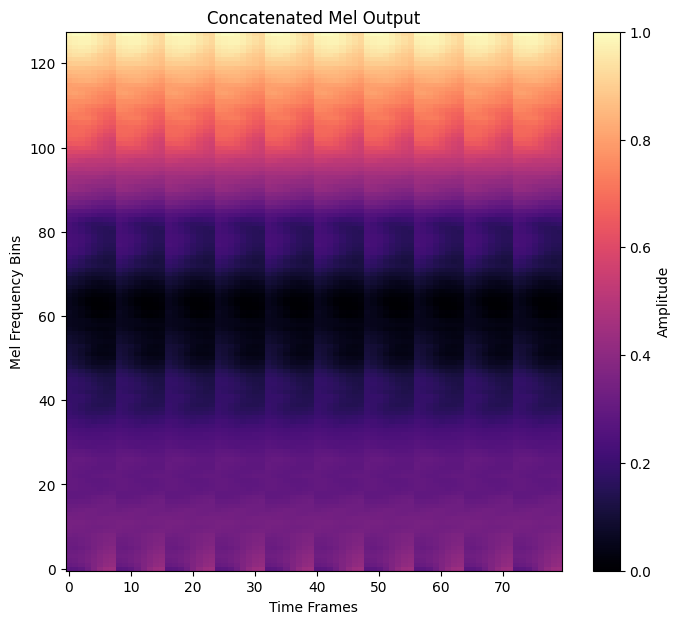

In [12]:
# Concatenate output multiple times to see latent trajectory
n = 10


# output_concat = torch.cat((output*0., output, output*0., output, output, output, output, output, output, output, output), dim=-1)
output_concat = torch.cat([output]*n, dim=-1)
# output_concat[0, :, 56:63] = 0.
print(f'output_concat.shape: {output_concat.shape}')
print(f'Value range: {torch.min(output_concat)} to {torch.max(output_concat)}')
# output_concat = F.pad(output, (10, 10), mode="constant", value=1)
plot_mel_spectrogram(output_concat.detach(), title='Concatenated Mel Output', dB_scale=False)

z_enc.shape: torch.Size([1, 16, 10])


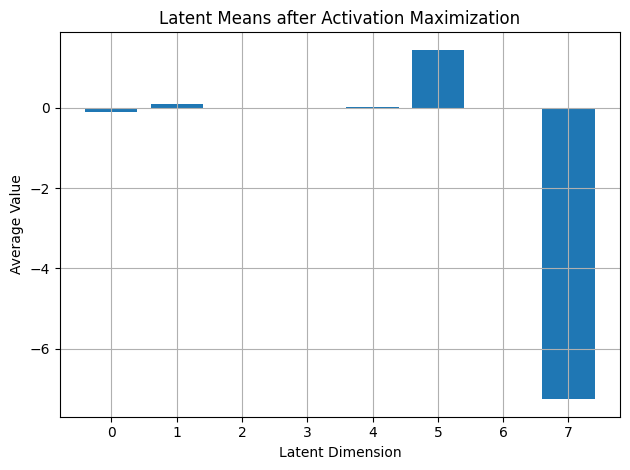

In [13]:
def plot_latent_means(latent_means, title='Latent Means', save_path=None):
    """
    Plots the average value of each latent mean across time frames.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    averages = latent_means.squeeze(0).mean(dim=1).detach()  # Average over time frames
    plt.bar(np.arange(len(averages)), averages)
    plt.title(title)
    plt.xlabel('Latent Dimension')
    plt.ylabel('Average Value')
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


z_enc = model.encoder(output_concat)
means, logscales = torch.split(z_enc, z_enc.shape[1] // 2, 1)
print(f'z_enc.shape: {z_enc.shape}')
plot_latent_means(means, title='Latent Means after Activation Maximization')

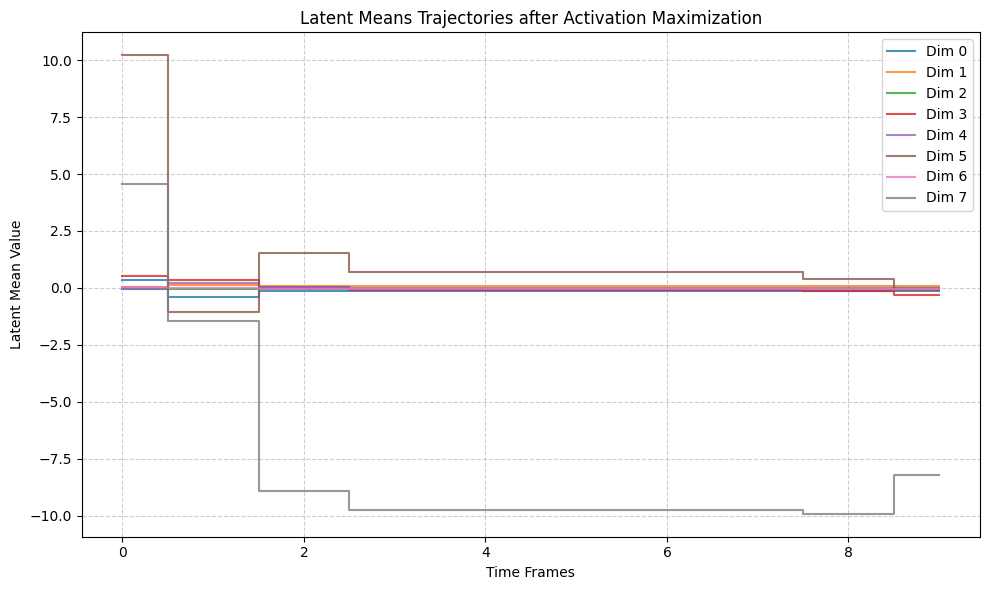

In [14]:
def plot_latent_trajectories(
    latent_means,
    title='Latent Means Trajectories',
    save_path=None
):
    """
    Plots the trajectories of latent means over time using step plots.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    latent_np = latent_means.squeeze(0).cpu().detach().numpy()
    T = latent_np.shape[1]  # number of timesteps

    plt.figure(figsize=(10, 6))
    for dim in range(latent_np.shape[0]):
        plt.step(
            range(T),
            latent_np[dim, :],
            where='mid',
            alpha=0.8,
            label=f'Dim {dim}'
        )

    plt.title(title)
    plt.xlabel('Time Frames')
    plt.ylabel('Latent Mean Value')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    
plot_latent_trajectories(means, title='Latent Means Trajectories after Activation Maximization')